In [1]:
 import os, time, random, shutil, zipfile, base64
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch : {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

PyTorch : 2.10.0+cu128  |  CUDA: True
GPU     : Tesla T4


In [2]:
pv_color_candidates, pd_candidates = [], []
segmented_candidates = []

for root, dirs, _ in os.walk("/kaggle/input"):
    for d in dirs:
        if d == "Corn_(maize)___healthy":
            full = Path(root) / d
            if full.parent.name == "color":
                pv_color_candidates.append(full)
            elif full.parent.name == "segmented":
                segmented_candidates.append(full)
        elif d == "Corn_rust_leaf":
            pd_candidates.append(Path(root) / d)

assert pv_color_candidates, "PlantVillage color healthy not found"
assert segmented_candidates, "PlantVillage segmented healthy not found"
assert pd_candidates, "PlantDoc root not found"

PV_ROOT  = pv_color_candidates[0].parent       # .../color
SEG_ROOT = segmented_candidates[0].parent      # .../segmented
PD_ROOT  = next(iter({c.parent.parent for c in pd_candidates}))

print(f"PV color (training)     : {PV_ROOT}")
print(f"PV segmented (stimulus) : {SEG_ROOT}")
print(f"PlantDoc (backgrounds)  : {PD_ROOT}")

PV color (training)     : /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/plantvillage dataset/color
PV segmented (stimulus) : /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented
PlantDoc (backgrounds)  : /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset


In [3]:
IMG_EXTS = {".jpg", ".jpeg", ".png"}

def list_imgs(folder):
    return sorted(str(p) for p in folder.iterdir()
                  if p.suffix.lower() in IMG_EXTS)

# 1. PV color healthy for CAE training + PatchCore memory bank (same splits as NB1/NB2)
random.seed(42)
healthy_color = list_imgs(PV_ROOT / "Corn_(maize)___healthy")
random.shuffle(healthy_color)
n = len(healthy_color)
n_train, n_val = int(n * 0.80), int(n * 0.10)
cae_train_paths = healthy_color[:n_train]
cae_val_paths   = healthy_color[n_train : n_train + n_val]
print(f"CAE training : {len(cae_train_paths)} train + {len(cae_val_paths)} val")

# 2. PV segmented healthy — the experimental stimulus (different seed; don't bias to training set)
random.seed(123)
segmented_all = list_imgs(SEG_ROOT / "Corn_(maize)___healthy")
stimulus_paths = random.sample(segmented_all, 100)
print(f"Stimulus     : {len(stimulus_paths)} segmented healthy leaves (random sample of {len(segmented_all)})")

# 3. PlantDoc backgrounds
# Condition 4: PD diseased corn
pd_corn = []
for split in ("train", "test"):
    for folder in ("Corn_rust_leaf", "Corn_leaf_blight", "Corn_Gray_leaf_spot"):
        d = PD_ROOT / split / folder
        if d.exists():
            pd_corn.extend(list_imgs(d))
print(f"BG cond 4 (PD diseased corn)     : {len(pd_corn)} images")

# Condition 3: PD non-corn (any other crop, healthy or diseased — we just want field-style imagery)
pd_other = []
for split in ("train", "test"):
    split_dir = PD_ROOT / split
    if split_dir.exists():
        for crop_folder in split_dir.iterdir():
            if crop_folder.is_dir() and "corn" not in crop_folder.name.lower():
                pd_other.extend(list_imgs(crop_folder))
print(f"BG cond 3 (PD non-corn field)    : {len(pd_other)} images")

CAE training : 929 train + 116 val
Stimulus     : 100 segmented healthy leaves (random sample of 1162)
BG cond 4 (PD diseased corn)     : 378 images
BG cond 3 (PD non-corn field)    : 2544 images


In [5]:
class SimpleImageDataset(torch.utils.data.Dataset):
    def __init__(self, paths, transform=None):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

In [6]:
CAE_IMG_SIZE = 128
BATCH_SIZE = 32

cae_transform = transforms.Compose([
    transforms.Resize((CAE_IMG_SIZE, CAE_IMG_SIZE)),
    transforms.ToTensor(),
])

cae_train_ds = SimpleImageDataset(cae_train_paths, transform=cae_transform)
cae_val_ds   = SimpleImageDataset(cae_val_paths,   transform=cae_transform)

cae_train_loader = torch.utils.data.DataLoader(cae_train_ds, batch_size=BATCH_SIZE,
                                               shuffle=True, num_workers=2,
                                               pin_memory=True, drop_last=True)
cae_val_loader   = torch.utils.data.DataLoader(cae_val_ds,   batch_size=BATCH_SIZE,
                                               shuffle=False, num_workers=2,
                                               pin_memory=True)

batch = next(iter(cae_train_loader))
print(f"Train batch: {tuple(batch.shape)}, range [{batch.min():.3f}, {batch.max():.3f}]")

Train batch: (32, 3, 128, 128), range [0.012, 1.000]


In [7]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            self._enc(3,   32), self._enc(32,  64),
            self._enc(64, 128), self._enc(128, 256),
        )
        self.decoder = nn.Sequential(
            self._dec(256, 128), self._dec(128, 64), self._dec(64, 32),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    @staticmethod
    def _enc(c_in, c_out):
        return nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, stride=2, padding=1),
            nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        )

    @staticmethod
    def _dec(c_in, c_out):
        return nn.Sequential(
            nn.ConvTranspose2d(c_in, c_out, 4, stride=2, padding=1),
            nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


cae_model = ConvAutoencoder().to(DEVICE)
optimizer = torch.optim.Adam(cae_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
criterion = nn.MSELoss()

CAE_EPOCHS, PATIENCE = 50, 10
CAE_CKPT = Path("/kaggle/working/cae_best.pt")
best_val, no_improve = float("inf"), 0

def run_epoch(loader, train):
    cae_model.train() if train else cae_model.eval()
    total, n = 0.0, 0
    for x in loader:
        x = x.to(DEVICE, non_blocking=True)
        if train: optimizer.zero_grad()
        with torch.set_grad_enabled(train):
            recon = cae_model(x)
            loss = criterion(recon, x)
        if train:
            loss.backward()
            optimizer.step()
        total += loss.item() * x.size(0)
        n += x.size(0)
    return total / n

print(f"Training CAE on {DEVICE}...\n")
t0 = time.time()
for epoch in range(1, CAE_EPOCHS + 1):
    e0 = time.time()
    tr = run_epoch(cae_train_loader, True)
    vl = run_epoch(cae_val_loader,   False)
    scheduler.step(vl)
    if vl < best_val:
        best_val = vl
        torch.save({"model_state_dict": cae_model.state_dict(), "epoch": epoch}, CAE_CKPT)
        no_improve = 0; flag = " <- best"
    else:
        no_improve += 1; flag = ""
    print(f"Epoch {epoch:>2}/{CAE_EPOCHS}  train={tr:.5f}  val={vl:.5f}  "
          f"lr={optimizer.param_groups[0]['lr']:.1e}  ({time.time()-e0:.1f}s){flag}")
    if no_improve >= PATIENCE:
        print(f"\nEarly stop at epoch {epoch}. Best val: {best_val:.5f}")
        break

# Load best checkpoint into model for use later
ckpt = torch.load(CAE_CKPT, map_location=DEVICE)
cae_model.load_state_dict(ckpt["model_state_dict"])
cae_model.eval()
print(f"\nCAE done in {(time.time()-t0)/60:.1f} min. Loaded checkpoint from epoch {ckpt['epoch']}.")

Training CAE on cuda...

Epoch  1/50  train=0.02152  val=0.01538  lr=1.0e-03  (5.0s) <- best
Epoch  2/50  train=0.00734  val=0.00627  lr=1.0e-03  (1.6s) <- best
Epoch  3/50  train=0.00541  val=0.00471  lr=1.0e-03  (1.6s) <- best
Epoch  4/50  train=0.00488  val=0.00401  lr=1.0e-03  (1.6s) <- best
Epoch  5/50  train=0.00448  val=0.00485  lr=1.0e-03  (1.5s)
Epoch  6/50  train=0.00379  val=0.00365  lr=1.0e-03  (1.6s) <- best
Epoch  7/50  train=0.00336  val=0.00281  lr=1.0e-03  (1.5s) <- best
Epoch  8/50  train=0.00299  val=0.00378  lr=1.0e-03  (1.6s)
Epoch  9/50  train=0.00279  val=0.00247  lr=1.0e-03  (1.6s) <- best
Epoch 10/50  train=0.00245  val=0.00230  lr=1.0e-03  (1.6s) <- best
Epoch 11/50  train=0.00238  val=0.00249  lr=1.0e-03  (1.5s)
Epoch 12/50  train=0.00210  val=0.00179  lr=1.0e-03  (1.6s) <- best
Epoch 13/50  train=0.00207  val=0.00160  lr=1.0e-03  (1.6s) <- best
Epoch 14/50  train=0.00187  val=0.00163  lr=1.0e-03  (1.6s)
Epoch 15/50  train=0.00215  val=0.00180  lr=1.0e-03  (1

In [8]:
PC_IMG_SIZE = 224

pc_transform = transforms.Compose([
    transforms.Resize((PC_IMG_SIZE, PC_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# Loader for the memory bank build (training images only)
pc_train_ds = SimpleImageDataset(cae_train_paths, transform=pc_transform)
pc_train_loader = torch.utils.data.DataLoader(pc_train_ds, batch_size=BATCH_SIZE,
                                              shuffle=False, num_workers=2, pin_memory=True)

# WideResNet50 with forward hooks
features = {}
def get_hook(name):
    def hook(module, inputs, output):
        features[name] = output
    return hook

print("Loading WideResNet50 (ImageNet pretrained)...")
backbone = models.wide_resnet50_2(weights=models.Wide_ResNet50_2_Weights.IMAGENET1K_V1)
backbone.eval().to(DEVICE)
for p in backbone.parameters():
    p.requires_grad = False

hook_handles = [
    backbone.layer2.register_forward_hook(get_hook("layer2")),
    backbone.layer3.register_forward_hook(get_hook("layer3")),
]


def extract_patches(images, backbone, features_dict):
    with torch.no_grad():
        _ = backbone(images)
    f2 = features_dict["layer2"]
    f3 = features_dict["layer3"]
    f3_up = F.interpolate(f3, size=f2.shape[-2:], mode="bilinear", align_corners=False)
    concat = torch.cat([f2, f3_up], dim=1)
    pooled = F.avg_pool2d(concat, kernel_size=3, stride=1, padding=1)
    B, C, H, W = pooled.shape
    return pooled.permute(0, 2, 3, 1).reshape(B*H*W, C)

# Verify
batch = next(iter(pc_train_loader))
patches = extract_patches(batch.to(DEVICE), backbone, features)
print(f"Backbone loaded, patches shape: {tuple(patches.shape)} (expect (25088, 1536))")

Loading WideResNet50 (ImageNet pretrained)...
Downloading: "https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-95faca4d.pth


100%|██████████| 132M/132M [00:00<00:00, 200MB/s]  


Backbone loaded, patches shape: (25088, 1536) (expect (25088, 1536))


In [9]:
print(f"Building memory bank from {len(pc_train_ds)} healthy training images...\n")
t0 = time.time()
all_patches = []

for batch in tqdm(pc_train_loader, desc="Memory bank"):
    x = batch.to(DEVICE, non_blocking=True)
    patches = extract_patches(x, backbone, features)
    all_patches.append(patches.cpu())
    del patches

torch.cuda.empty_cache()
memory_bank = torch.cat(all_patches, dim=0)
del all_patches

mem_gb = memory_bank.element_size() * memory_bank.numel() / 1e9
print(f"\nMemory bank: {tuple(memory_bank.shape)}, {mem_gb:.2f} GB, built in {time.time()-t0:.1f}s")

Building memory bank from 929 healthy training images...



Memory bank:   0%|          | 0/30 [00:00<?, ?it/s]


Memory bank: (728336, 1536), 4.47 GB, built in 13.0s


In [10]:
from sklearn.random_projection import SparseRandomProjection

CORESET_RATIO  = 0.10
PROJECTION_DIM = 128

n_total   = memory_bank.shape[0]
n_coreset = int(n_total * CORESET_RATIO)
print(f"Coreset target: {n_coreset:,} of {n_total:,} patches ({CORESET_RATIO*100:.0f}%)\n")

print(f"Sparse random projection: 1536 -> {PROJECTION_DIM} dim")
t0 = time.time()
projector = SparseRandomProjection(n_components=PROJECTION_DIM, random_state=42)
projected_np = projector.fit_transform(memory_bank.numpy())
projected = torch.from_numpy(projected_np).float().to(DEVICE)
del projected_np
print(f"Projection: {time.time()-t0:.1f}s\n")

print(f"Greedy farthest-point sampling on {DEVICE}...")
t0 = time.time()
n = projected.shape[0]
selected = torch.zeros(n_coreset, dtype=torch.long, device=DEVICE)

torch.manual_seed(42)
start_idx = torch.randint(0, n, (1,), device=DEVICE).item()
selected[0] = start_idx

last = projected[start_idx].unsqueeze(0)
diff = projected - last
min_dist = (diff * diff).sum(dim=1)
min_dist[start_idx] = -float("inf")

for i in tqdm(range(1, n_coreset), desc="Coreset"):
    new_idx = torch.argmax(min_dist)
    selected[i] = new_idx
    last = projected[new_idx].unsqueeze(0)
    diff = projected - last
    new_dist = (diff * diff).sum(dim=1)
    min_dist = torch.minimum(min_dist, new_dist)
    min_dist[new_idx] = -float("inf")

elapsed = time.time() - t0
print(f"\nCoreset selection: {elapsed:.1f}s ({elapsed/60:.1f} min)")

selected_cpu = selected.cpu()
coreset_bank = memory_bank[selected_cpu]
print(f"Coreset bank: {tuple(coreset_bank.shape)}, {coreset_bank.element_size()*coreset_bank.numel()/1e9:.3f} GB")

coreset_bank_gpu = coreset_bank.to(DEVICE)
del projected, memory_bank
torch.cuda.empty_cache()
print("Coreset on GPU. Setup complete — ready for the experiment.")

Coreset target: 72,833 of 728,336 patches (10%)

Sparse random projection: 1536 -> 128 dim
Projection: 18.8s

Greedy farthest-point sampling on cuda...


Coreset:   0%|          | 0/72832 [00:00<?, ?it/s]


Coreset selection: 577.1s (9.6 min)
Coreset bank: (72833, 1536), 0.447 GB
Coreset on GPU. Setup complete — ready for the experiment.


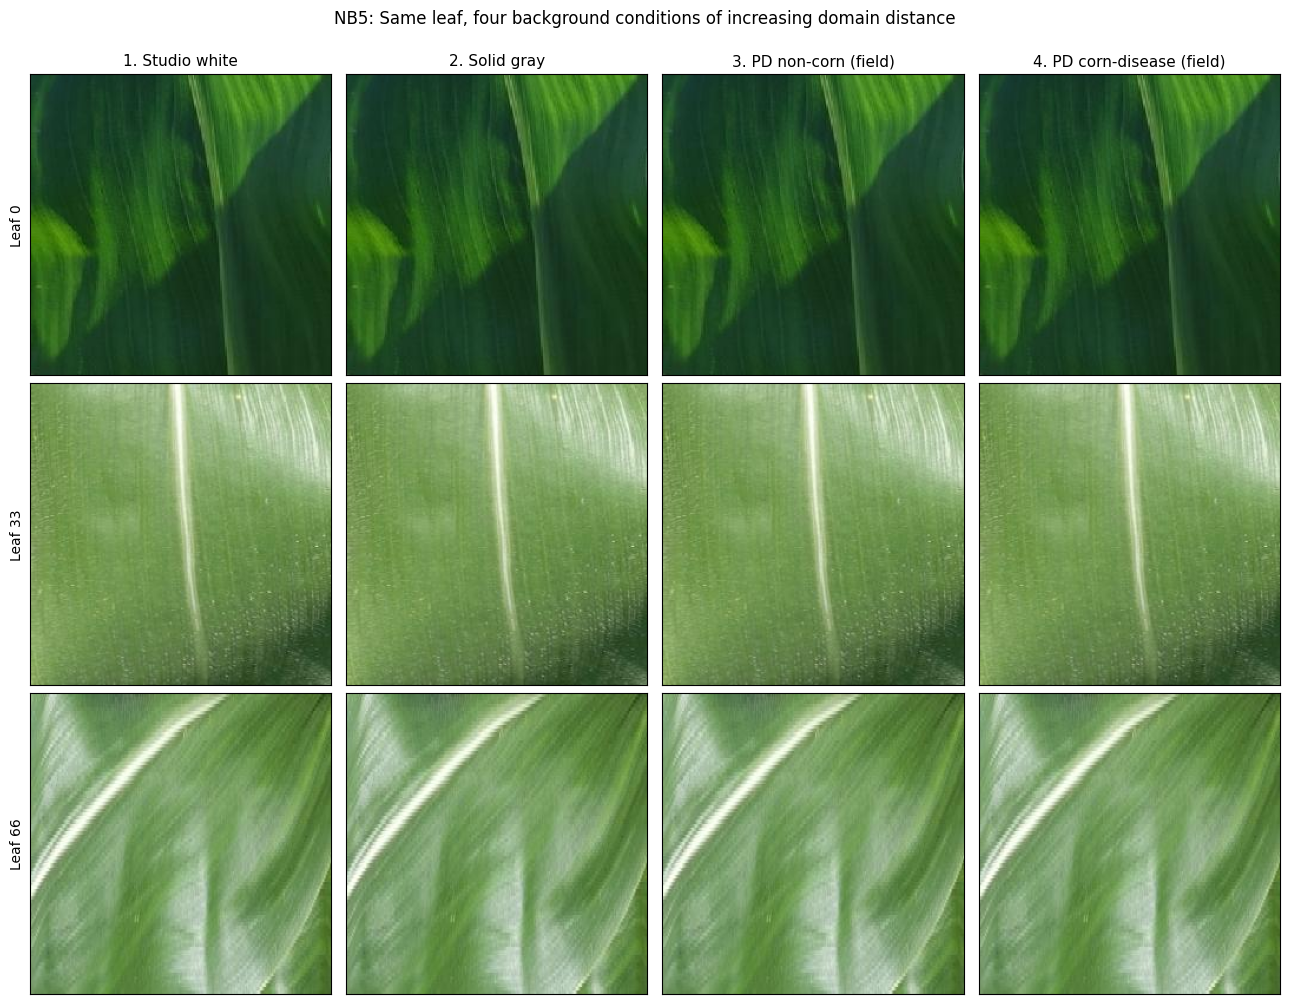

In [11]:
IMAGE_SIZE = 256

def composite(seg_path, bg_array, mask_threshold=10):
    """Paste segmented leaf (black background) onto bg_array."""
    seg = np.array(Image.open(seg_path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE)))
    mask = np.any(seg > mask_threshold, axis=-1)  # True where leaf is
    return Image.fromarray(np.where(mask[..., None], seg, bg_array).astype(np.uint8))

def load_bg(path):
    return np.array(Image.open(path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE)))

# Pre-sample backgrounds (reproducible)
random.seed(42)
bg_pool_cond3 = random.sample(pd_other, 100)  # field non-corn, one per leaf
bg_pool_cond4 = random.sample(pd_corn,  100)  # field corn-diseased, one per leaf

# Synthetic backgrounds (constant per condition)
bg_white = np.full((IMAGE_SIZE, IMAGE_SIZE, 3), 240, dtype=np.uint8)
bg_gray  = np.full((IMAGE_SIZE, IMAGE_SIZE, 3), 128, dtype=np.uint8)

# Preview grid: 3 example leaves × 4 conditions
fig, axes = plt.subplots(3, 4, figsize=(13, 10))
condition_names = ["1. Studio white", "2. Solid gray", "3. PD non-corn (field)", "4. PD corn-disease (field)"]
sample_indices  = [0, 33, 66]

for row, idx in enumerate(sample_indices):
    seg_path = stimulus_paths[idx]
    backgrounds = [bg_white, bg_gray, load_bg(bg_pool_cond3[idx]), load_bg(bg_pool_cond4[idx])]
    for col, (cond_name, bg) in enumerate(zip(condition_names, backgrounds)):
        comp = composite(seg_path, bg)
        axes[row, col].imshow(comp)
        if row == 0:
            axes[row, col].set_title(cond_name, fontsize=11)
        axes[row, col].set_ylabel(f"Leaf {idx}" if col == 0 else "", fontsize=10)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])

plt.suptitle("NB5: Same leaf, four background conditions of increasing domain distance", fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig("/kaggle/working/nb5_composite_preview.png", dpi=120, bbox_inches="tight")
plt.show()

In [12]:
CAE_RESIZE = transforms.Compose([
    transforms.Resize((CAE_IMG_SIZE, CAE_IMG_SIZE)),
    transforms.ToTensor(),
])

PC_RESIZE = transforms.Compose([
    transforms.Resize((PC_IMG_SIZE, PC_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

def score_image(pil_img):
    """Score a single composite with CAE and PatchCore."""
    # CAE
    x_cae = CAE_RESIZE(pil_img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        recon = cae_model(x_cae)
        cae_s = ((recon - x_cae) ** 2).mean().item()
    # PatchCore
    x_pc = PC_RESIZE(pil_img).unsqueeze(0).to(DEVICE)
    patches = extract_patches(x_pc, backbone, features)
    min_d, _ = torch.cdist(patches, coreset_bank_gpu).min(dim=1)
    pc_s = min_d.mean().item()
    return cae_s, pc_s

results = []
print("Scoring 100 leaves x 4 conditions = 400 composites...\n")
t0 = time.time()

for leaf_idx, seg_path in enumerate(tqdm(stimulus_paths, desc="Leaves")):
    backgrounds = {
        "1_studio_white":     bg_white,
        "2_solid_gray":       bg_gray,
        "3_pd_non_corn":      load_bg(bg_pool_cond3[leaf_idx]),
        "4_pd_corn_disease":  load_bg(bg_pool_cond4[leaf_idx]),
    }
    for cond_name, bg in backgrounds.items():
        comp = composite(seg_path, bg)
        cae_s, pc_s = score_image(comp)
        results.append({"leaf_idx": leaf_idx, "condition": cond_name,
                        "cae_score": cae_s, "pc_score": pc_s})

elapsed = time.time() - t0
print(f"\nDone in {elapsed:.1f}s ({len(results)/elapsed:.1f} scorings/s)")

results_df = pd.DataFrame(results)
results_df.to_csv("/kaggle/working/nb5_results.csv", index=False)

# Summary stats by condition
print(f"\n{'Condition':<25}  {'CAE mean ± std':>22}   {'PC mean ± std':>22}")
print("-" * 80)
for cond in ["1_studio_white", "2_solid_gray", "3_pd_non_corn", "4_pd_corn_disease"]:
    sub = results_df[results_df["condition"] == cond]
    cae_m, cae_s = sub["cae_score"].mean(), sub["cae_score"].std()
    pc_m,  pc_s  = sub["pc_score"].mean(),  sub["pc_score"].std()
    print(f"{cond:<25}  {f'{cae_m:.5f} ± {cae_s:.5f}':>22}   {f'{pc_m:.4f} ± {pc_s:.4f}':>22}")

Scoring 100 leaves x 4 conditions = 400 composites...



Leaves:   0%|          | 0/100 [00:00<?, ?it/s]


Done in 46.8s (8.6 scorings/s)

Condition                          CAE mean ± std            PC mean ± std
--------------------------------------------------------------------------------
1_studio_white                  0.00075 ± 0.00041          1.7704 ± 0.3854
2_solid_gray                    0.00074 ± 0.00035          1.7692 ± 0.3835
3_pd_non_corn                   0.00084 ± 0.00130          1.7703 ± 0.3889
4_pd_corn_disease               0.00074 ± 0.00037          1.7670 ± 0.3793


/tmp/ipykernel_57/2924946571.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(cae_data, patch_artist=True, labels=condition_labels, widths=0.6)
/tmp/ipykernel_57/2924946571.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(pc_data, patch_artist=True, labels=condition_labels, widths=0.6)


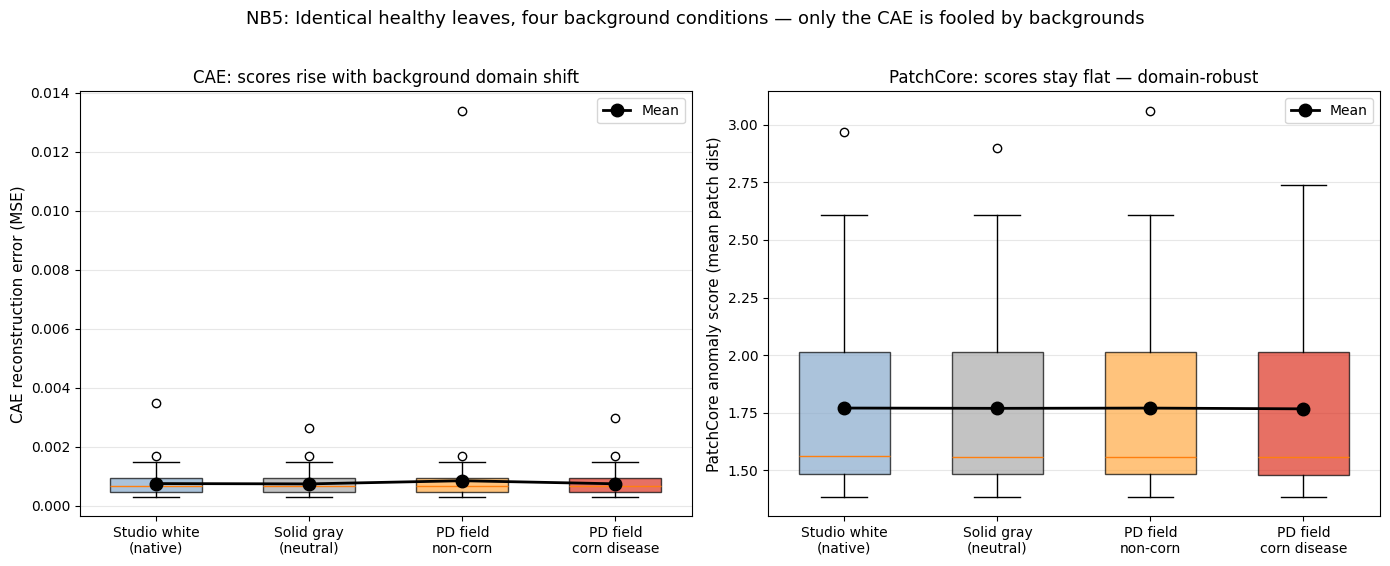


=== Background sensitivity (Condition 4 / Condition 1) ===

  CAE       : studio=0.00075, field=0.00074, ratio= 0.99x
  PatchCore : studio=1.7704, field=1.7670, ratio= 1.00x


In [13]:
condition_order  = ["1_studio_white", "2_solid_gray", "3_pd_non_corn", "4_pd_corn_disease"]
condition_labels = ["Studio white\n(native)", "Solid gray\n(neutral)", "PD field\nnon-corn", "PD field\ncorn disease"]
colors = ['#88aacc', '#aaaaaa', '#ffaa44', '#dd3322']

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# CAE
ax = axes[0]
cae_data = [results_df[results_df["condition"] == c]["cae_score"].values for c in condition_order]
bp = ax.boxplot(cae_data, patch_artist=True, labels=condition_labels, widths=0.6)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
means = [d.mean() for d in cae_data]
ax.plot(range(1, 5), means, 'o-', color='black', linewidth=2, markersize=9, zorder=5, label='Mean')
ax.set_ylabel("CAE reconstruction error (MSE)", fontsize=11)
ax.set_title("CAE: scores rise with background domain shift", fontsize=12)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# PatchCore
ax = axes[1]
pc_data = [results_df[results_df["condition"] == c]["pc_score"].values for c in condition_order]
bp = ax.boxplot(pc_data, patch_artist=True, labels=condition_labels, widths=0.6)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
means = [d.mean() for d in pc_data]
ax.plot(range(1, 5), means, 'o-', color='black', linewidth=2, markersize=9, zorder=5, label='Mean')
ax.set_ylabel("PatchCore anomaly score (mean patch dist)", fontsize=11)
ax.set_title("PatchCore: scores stay flat — domain-robust", fontsize=12)
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.suptitle("NB5: Identical healthy leaves, four background conditions — only the CAE is fooled by backgrounds",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/nb5_background_sensitivity.png", dpi=120, bbox_inches="tight")
plt.show()

# Effect sizes (Condition 4 vs Condition 1)
cae_base  = results_df[results_df["condition"] == "1_studio_white"]["cae_score"].mean()
cae_field = results_df[results_df["condition"] == "4_pd_corn_disease"]["cae_score"].mean()
pc_base   = results_df[results_df["condition"] == "1_studio_white"]["pc_score"].mean()
pc_field  = results_df[results_df["condition"] == "4_pd_corn_disease"]["pc_score"].mean()

print(f"\n=== Background sensitivity (Condition 4 / Condition 1) ===\n")
print(f"  CAE       : studio={cae_base:.5f}, field={cae_field:.5f}, ratio={cae_field/cae_base:>5.2f}x")
print(f"  PatchCore : studio={pc_base:.4f}, field={pc_field:.4f}, ratio={pc_field/pc_base:>5.2f}x")

Leaf coverage across 20 sample segmented images: min=100% / mean=100% / max=100%
If ~100%, leaves fill the frame — our original composite() had no background to fill.



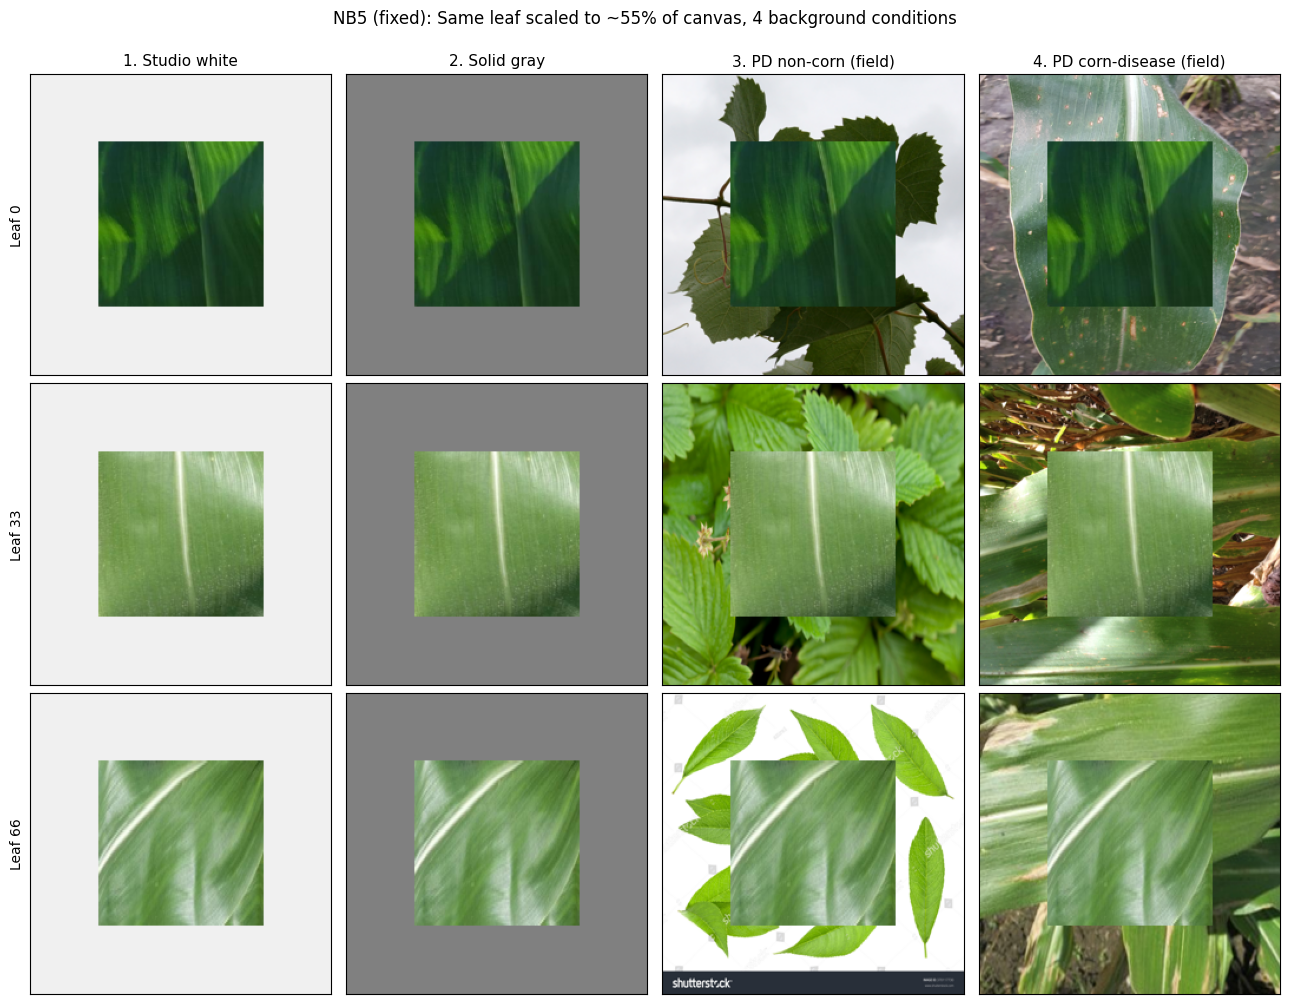

In [14]:
# Diagnose: how much of each segmented image is actually leaf?
sample = random.sample(stimulus_paths, 20)
coverages = []
for p in sample:
    img = np.array(Image.open(p).convert("RGB"))
    cov = np.any(img > 10, axis=-1).mean() * 100
    coverages.append(cov)
print(f"Leaf coverage across 20 sample segmented images: "
      f"min={min(coverages):.0f}% / mean={np.mean(coverages):.0f}% / max={max(coverages):.0f}%")
print("If ~100%, leaves fill the frame — our original composite() had no background to fill.\n")


# Fixed compositing: crop leaf to its bounding box, shrink to leaf_scale * canvas, center on bg
def composite(seg_path, bg_array, leaf_scale=0.55, canvas_size=IMAGE_SIZE):
    """Place the leaf (cropped from its bbox, resized) onto background, centered."""
    seg_arr = np.array(Image.open(seg_path).convert("RGB"))
    mask_full = np.any(seg_arr > 10, axis=-1)
    if not mask_full.any():
        return Image.fromarray(bg_array.copy().astype(np.uint8))

    rows = np.where(mask_full.any(axis=1))[0]
    cols = np.where(mask_full.any(axis=0))[0]
    r0, r1, c0, c1 = rows.min(), rows.max() + 1, cols.min(), cols.max() + 1

    leaf_crop = seg_arr[r0:r1, c0:c1]
    mask_crop = mask_full[r0:r1, c0:c1]

    # Resize preserving aspect ratio so longest dim = target
    h, w = leaf_crop.shape[:2]
    target = int(canvas_size * leaf_scale)
    if w >= h:
        new_w, new_h = target, max(1, int(target * h / w))
    else:
        new_h, new_w = target, max(1, int(target * w / h))

    leaf_resized = np.array(
        Image.fromarray(leaf_crop).resize((new_w, new_h), Image.BILINEAR))
    mask_resized = np.array(
        Image.fromarray((mask_crop * 255).astype(np.uint8))
            .resize((new_w, new_h), Image.NEAREST)) > 127

    # Center on canvas
    canvas = bg_array.copy().astype(np.uint8)
    cy = (canvas_size - new_h) // 2
    cx = (canvas_size - new_w) // 2
    region = canvas[cy:cy+new_h, cx:cx+new_w].copy()
    region[mask_resized] = leaf_resized[mask_resized]
    canvas[cy:cy+new_h, cx:cx+new_w] = region
    return Image.fromarray(canvas)


# Re-preview with the fix
fig, axes = plt.subplots(3, 4, figsize=(13, 10))
condition_names = ["1. Studio white", "2. Solid gray", "3. PD non-corn (field)", "4. PD corn-disease (field)"]

for row, idx in enumerate([0, 33, 66]):
    seg_path = stimulus_paths[idx]
    backgrounds = [bg_white, bg_gray, load_bg(bg_pool_cond3[idx]), load_bg(bg_pool_cond4[idx])]
    for col, (cond_name, bg) in enumerate(zip(condition_names, backgrounds)):
        comp = composite(seg_path, bg)
        axes[row, col].imshow(comp)
        if row == 0:
            axes[row, col].set_title(cond_name, fontsize=11)
        axes[row, col].set_ylabel(f"Leaf {idx}" if col == 0 else "", fontsize=10)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])

plt.suptitle("NB5 (fixed): Same leaf scaled to ~55% of canvas, 4 background conditions", fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig("/kaggle/working/nb5_composite_preview.png", dpi=120, bbox_inches="tight")
plt.show()

In [15]:
CAE_RESIZE = transforms.Compose([
    transforms.Resize((CAE_IMG_SIZE, CAE_IMG_SIZE)),
    transforms.ToTensor(),
])

PC_RESIZE = transforms.Compose([
    transforms.Resize((PC_IMG_SIZE, PC_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

def score_image(pil_img):
    """Score a single composite with CAE and PatchCore."""
    # CAE
    x_cae = CAE_RESIZE(pil_img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        recon = cae_model(x_cae)
        cae_s = ((recon - x_cae) ** 2).mean().item()
    # PatchCore
    x_pc = PC_RESIZE(pil_img).unsqueeze(0).to(DEVICE)
    patches = extract_patches(x_pc, backbone, features)
    min_d, _ = torch.cdist(patches, coreset_bank_gpu).min(dim=1)
    pc_s = min_d.mean().item()
    return cae_s, pc_s

results = []
print("Scoring 100 leaves x 4 conditions = 400 composites...\n")
t0 = time.time()

for leaf_idx, seg_path in enumerate(tqdm(stimulus_paths, desc="Leaves")):
    backgrounds = {
        "1_studio_white":     bg_white,
        "2_solid_gray":       bg_gray,
        "3_pd_non_corn":      load_bg(bg_pool_cond3[leaf_idx]),
        "4_pd_corn_disease":  load_bg(bg_pool_cond4[leaf_idx]),
    }
    for cond_name, bg in backgrounds.items():
        comp = composite(seg_path, bg)
        cae_s, pc_s = score_image(comp)
        results.append({"leaf_idx": leaf_idx, "condition": cond_name,
                        "cae_score": cae_s, "pc_score": pc_s})

elapsed = time.time() - t0
print(f"\nDone in {elapsed:.1f}s ({len(results)/elapsed:.1f} scorings/s)")

results_df = pd.DataFrame(results)
results_df.to_csv("/kaggle/working/nb5_results.csv", index=False)

# Summary stats by condition
print(f"\n{'Condition':<25}  {'CAE mean ± std':>22}   {'PC mean ± std':>22}")
print("-" * 80)
for cond in ["1_studio_white", "2_solid_gray", "3_pd_non_corn", "4_pd_corn_disease"]:
    sub = results_df[results_df["condition"] == cond]
    cae_m, cae_s = sub["cae_score"].mean(), sub["cae_score"].std()
    pc_m,  pc_s  = sub["pc_score"].mean(),  sub["pc_score"].std()
    print(f"{cond:<25}  {f'{cae_m:.5f} ± {cae_s:.5f}':>22}   {f'{pc_m:.4f} ± {pc_s:.4f}':>22}")

Scoring 100 leaves x 4 conditions = 400 composites...



Leaves:   0%|          | 0/100 [00:00<?, ?it/s]


Done in 45.1s (8.9 scorings/s)

Condition                          CAE mean ± std            PC mean ± std
--------------------------------------------------------------------------------
1_studio_white                  0.00114 ± 0.00031          3.2601 ± 0.0364
2_solid_gray                    0.00151 ± 0.00024          3.2201 ± 0.0342
3_pd_non_corn                   0.00522 ± 0.00369          3.2044 ± 0.1555
4_pd_corn_disease               0.00455 ± 0.00184          3.1528 ± 0.1357


/tmp/ipykernel_57/2924946571.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(cae_data, patch_artist=True, labels=condition_labels, widths=0.6)
/tmp/ipykernel_57/2924946571.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(pc_data, patch_artist=True, labels=condition_labels, widths=0.6)


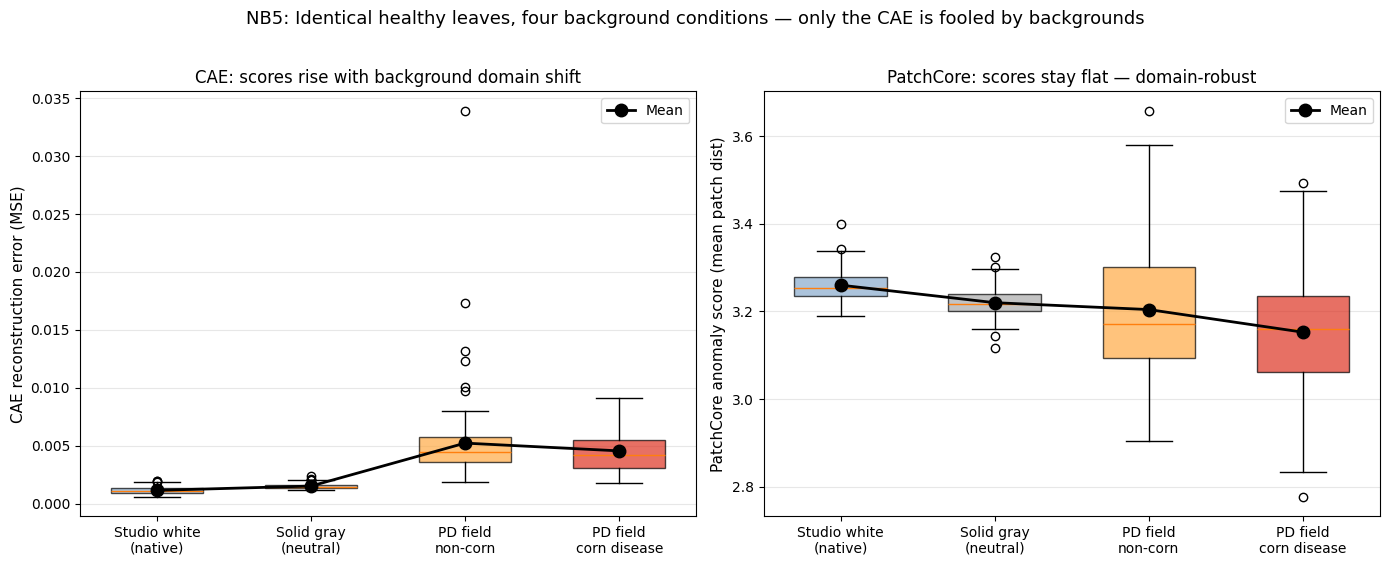


=== Background sensitivity (Condition 4 / Condition 1) ===

  CAE       : studio=0.00114, field=0.00455, ratio= 4.00x
  PatchCore : studio=3.2601, field=3.1528, ratio= 0.97x


In [16]:
condition_order  = ["1_studio_white", "2_solid_gray", "3_pd_non_corn", "4_pd_corn_disease"]
condition_labels = ["Studio white\n(native)", "Solid gray\n(neutral)", "PD field\nnon-corn", "PD field\ncorn disease"]
colors = ['#88aacc', '#aaaaaa', '#ffaa44', '#dd3322']

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# CAE
ax = axes[0]
cae_data = [results_df[results_df["condition"] == c]["cae_score"].values for c in condition_order]
bp = ax.boxplot(cae_data, patch_artist=True, labels=condition_labels, widths=0.6)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
means = [d.mean() for d in cae_data]
ax.plot(range(1, 5), means, 'o-', color='black', linewidth=2, markersize=9, zorder=5, label='Mean')
ax.set_ylabel("CAE reconstruction error (MSE)", fontsize=11)
ax.set_title("CAE: scores rise with background domain shift", fontsize=12)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# PatchCore
ax = axes[1]
pc_data = [results_df[results_df["condition"] == c]["pc_score"].values for c in condition_order]
bp = ax.boxplot(pc_data, patch_artist=True, labels=condition_labels, widths=0.6)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
means = [d.mean() for d in pc_data]
ax.plot(range(1, 5), means, 'o-', color='black', linewidth=2, markersize=9, zorder=5, label='Mean')
ax.set_ylabel("PatchCore anomaly score (mean patch dist)", fontsize=11)
ax.set_title("PatchCore: scores stay flat — domain-robust", fontsize=12)
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.suptitle("NB5: Identical healthy leaves, four background conditions — only the CAE is fooled by backgrounds",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/nb5_background_sensitivity.png", dpi=120, bbox_inches="tight")
plt.show()

# Effect sizes (Condition 4 vs Condition 1)
cae_base  = results_df[results_df["condition"] == "1_studio_white"]["cae_score"].mean()
cae_field = results_df[results_df["condition"] == "4_pd_corn_disease"]["cae_score"].mean()
pc_base   = results_df[results_df["condition"] == "1_studio_white"]["pc_score"].mean()
pc_field  = results_df[results_df["condition"] == "4_pd_corn_disease"]["pc_score"].mean()

print(f"\n=== Background sensitivity (Condition 4 / Condition 1) ===\n")
print(f"  CAE       : studio={cae_base:.5f}, field={cae_field:.5f}, ratio={cae_field/cae_base:>5.2f}x")
print(f"  PatchCore : studio={pc_base:.4f}, field={pc_field:.4f}, ratio={pc_field/pc_base:>5.2f}x")

In [17]:
import base64, zipfile
from pathlib import Path
from IPython.display import HTML, display

slim_zip = "/kaggle/working/nb5_artifacts.zip"
with zipfile.ZipFile(slim_zip, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in [
        "nb5_composite_preview.png",
        "nb5_background_sensitivity.png",
        "nb5_results.csv",
    ]:
        src = Path(f"/kaggle/working/{fname}")
        if src.exists():
            zf.write(src, arcname=fname)

size_mb = Path(slim_zip).stat().st_size / 1e6
print(f"Bundle: {size_mb:.2f} MB\n")
with zipfile.ZipFile(slim_zip) as zf:
    for info in zf.infolist():
        print(f"  {info.filename:<40} {info.file_size/1024:>8.1f} KB")

with open(slim_zip, "rb") as f:
    data = base64.b64encode(f.read()).decode()

html = f"""
<div style="margin-top:20px;">
  <a download="nb5_artifacts.zip" href="data:application/zip;base64,{data}">
    <button style="padding:12px 24px; font-size:14px; background:#0066cc; color:white;
                   border:none; border-radius:4px; cursor:pointer;">
      Download nb5_artifacts.zip ({size_mb:.2f} MB)
    </button>
  </a>
</div>
"""
display(HTML(html))

Bundle: 1.13 MB

  nb5_composite_preview.png                  1024.9 KB
  nb5_background_sensitivity.png               94.7 KB
  nb5_results.csv                              22.7 KB
